## Logistic Regression

I was hopefully going to create a classification model, originally that would have multiple classes based off of multiple features to potentially guess rank. Although, later on I realised my data was too small to accurately find a trend. I also tried to create a model that had all the classes included but it become to convoluted where there was no trend and KNN would have been more efficient at that point.

 Thus I planned to find the median rank amongst all the ranks and use that as foundation to create 3 classes that would allow for me to determine MMR. The plan was to identify performance through a sigmoid function using performance near "1" as above average and vice versa for low performance which is "-1" and the boundary would be for players in "Platinum". Conclusively, I've figured that absolutely no features have high correlation with any of the ranks to give an accurate prediction; thus I have scrapped Logistic_Regression.

### Import Dependencies

In [ ]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 

### Import CSV as variable

In [ ]:
players = pd.read_csv("2.3.1.training_data.csv")

### Plot features against Target

In [ ]:
# Import CSV as variable
players = pd.read_csv("2.3.1.training_data.csv")

# X: multiple input features (edit this list as needed)
feature_cols = ["performance", "k/d", "matchs_played", "avg_kill_per_rnd"]

# Keep only valid feature columns
feature_cols = [c for c in feature_cols if c in players.columns]
if not feature_cols:
    raise ValueError("No valid feature columns found.")

# y: rank_Platinum (handles duplicate names like 'rank_Platinum ')
platinum_cols = [c for c in players.columns if c.strip() == "rank_Platinum"]
if not platinum_cols:
    raise ValueError("rank_Platinum column not found.")

X = players[feature_cols].copy()
y = players[platinum_cols].astype(bool).any(axis=1).astype(int)

# Drop rows with missing X values
mask = X.notna().all(axis=1)
X = X.loc[mask]
y = y.loc[mask]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y classes:", sorted(y.unique()))

X shape: (286, 4)
y shape: (286,)
y classes: [np.int64(0), np.int64(1)]


### Instantiate Model

In [ ]:
val_regression = LogisticRegression()

### Fit model

In [ ]:
val_regression.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Plot predictions for quick evaluation of model

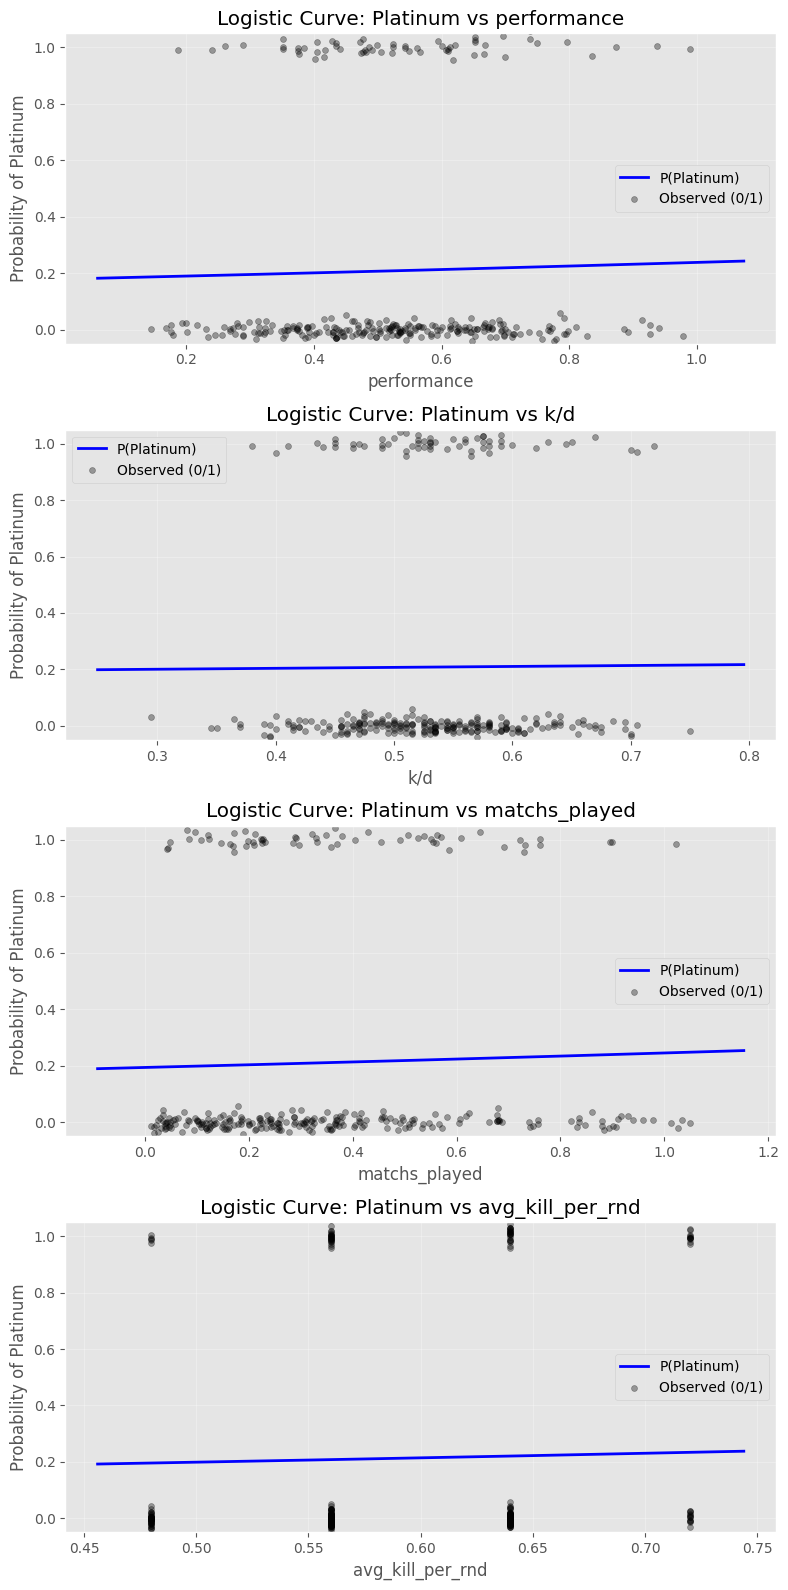

In [ ]:
# class index for Platinum=1
if 1 not in val_regression.classes_:
    raise ValueError("Class '1' (Platinum) not found in model classes.")
pos_idx = list(val_regression.classes_).index(1)

n = len(feature_cols)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(8, 4 * n), squeeze=False)

for i, fx in enumerate(feature_cols):
    ax = axes[i, 0]

    x_vals = X[fx].to_numpy()
    pad = (x_vals.max() - x_vals.min()) * 0.1 if x_vals.max() > x_vals.min() else 1.0
    x_grid = np.linspace(x_vals.min() - pad, x_vals.max() + pad, 400)

    # Build full feature grid: vary fx, hold others at median
    grid_df = pd.DataFrame(
        {col: X[col].median() for col in feature_cols}, index=range(len(x_grid))
    )
    grid_df[fx] = x_grid

    p_platinum = val_regression.predict_proba(grid_df)[:, pos_idx]

    ax.plot(x_grid, p_platinum, color="blue", linewidth=2, label="P(Platinum)")
    ax.scatter(
        X[fx],
        y + np.random.default_rng(42).normal(0, 0.02, size=len(y)),
        s=18,
        alpha=0.35,
        color="black",
        label="Observed (0/1)",
    )

    ax.set_title(f"Logistic Curve: Platinum vs {fx}")
    ax.set_xlabel(fx)
    ax.set_ylabel("Probability of Platinum")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### Pickle model in preparation for evaluation

In [ ]:
# save the model to disk
filename = "logistic_model.sav"
pickle.dump(val_regression, open("../2.4.Model_Testing_and_Evaluation/" + filename, "wb"))